In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import math
import os
import glob
import re

In [37]:
games_df = pd.read_csv('../data/raw/games.csv')

player_play_df = pd.read_csv('../data/raw/player_play.csv')

players_df = pd.read_csv('../data/raw/players.csv')


tracking_week1_df = pd.read_csv('../data/raw/tracking_week_1.csv')
tracking_week2_df = pd.read_csv('../data/raw/tracking_week_2.csv')
tracking_week3_df = pd.read_csv('../data/raw/tracking_week_3.csv')
tracking_week4_df = pd.read_csv('../data/raw/tracking_week_4.csv')
tracking_week5_df = pd.read_csv('../data/raw/tracking_week_5.csv')
tracking_week6_df = pd.read_csv('../data/raw/tracking_week_6.csv')
tracking_week7_df = pd.read_csv('../data/raw/tracking_week_7.csv')
tracking_week8_df = pd.read_csv('../data/raw/tracking_week_8.csv')
tracking_week9_df = pd.read_csv('../data/raw/tracking_week_9.csv')

In [38]:
tracking_dfs_with_week = []

for i, df in enumerate([tracking_week1_df, tracking_week2_df, tracking_week3_df, 
                        tracking_week4_df, tracking_week5_df, tracking_week6_df,
                        tracking_week7_df, tracking_week8_df, tracking_week9_df], 1):
    df_copy = df.copy()
    df_copy['week'] = i
    tracking_dfs_with_week.append(df_copy)

tracking_all_df = pd.concat(tracking_dfs_with_week, ignore_index=True)

In [39]:
print("\n## Basic Summary Statistics")
print("\nGames summary:")
display(games_df.describe())
print("\nPlayers summary:")
display(players_df.describe(include='all'))


## Basic Summary Statistics

Games summary:


,gameId,season,week,homeFinalScore,visitorFinalScore
count,1.360000e+02,136.0,136.000000,136.000000,136.000000
mean,2.022099e+09,2022.0,4.845588,22.669118,20.948529
std,5.996614e+03,0.0,2.567254,8.659874,9.731446
min,2.022091e+09,2022.0,1.000000,3.000000,0.000000
25%,2.022093e+09,2022.0,3.000000,17.000000,14.750000
50%,2.022101e+09,2022.0,5.000000,22.500000,20.000000
75%,2.022102e+09,2022.0,7.000000,27.000000,27.000000
max,2.022111e+09,2022.0,9.000000,49.000000,48.000000



Players summary:


,nflId,height,weight,birthDate,collegeName,position,displayName
count,1697.000000,1697,1697.000000,1210,1697,1697,1697
unique,NaN,16,NaN,989,225,19,1687
top,NaN,6-3,NaN,1995-03-21,Alabama,WR,Lamar Jackson
freq,NaN,258,NaN,4,59,224,2
mean,48237.157336,NaN,245.774308,NaN,NaN,NaN,NaN
std,5230.066814,NaN,47.256005,NaN,NaN,NaN,NaN
min,25511.000000,NaN,153.000000,NaN,NaN,NaN,NaN
25%,44830.000000,NaN,205.000000,NaN,NaN,NaN,NaN
50%,47874.000000,NaN,236.000000,NaN,NaN,NaN,NaN
75%,53476.000000,NaN,291.000000,NaN,NaN,NaN,NaN


# Plays EDA + Feature Engineering

In [40]:
plays_df = pd.read_csv('../data/raw/plays.csv', 
                      quotechar='"', 
                      na_values=['NA', 'na', 'N/A'],
                      true_values=['TRUE', 'True', 'true'],
                      false_values=['FALSE', 'False', 'false'],
                      dtype={'gameId': str, 'playId': int})

In [41]:
passing_plays = plays_df[plays_df['passResult'].notna()]
qb_features = passing_plays.copy()

In [42]:
# 1. OUTCOME METRICS
qb_features['completion'] = (qb_features['passResult'] == 'C').astype(int)
qb_features['epa'] = qb_features['expectedPointsAdded']
qb_features['epa_success'] = (qb_features['expectedPointsAdded'] > 0).astype(int)
qb_features['yards_gained'] = qb_features['yardsGained']


In [43]:
# 2. GAME SITUATION
qb_features['down'] = qb_features['down']
qb_features['yards_to_go'] = qb_features['yardsToGo']

qb_features['yards_from_goal'] = 100 - qb_features['absoluteYardlineNumber']
qb_features['red_zone'] = (qb_features['yards_from_goal'] <= 20).astype(int)

qb_features['home_win_prob'] = qb_features['preSnapHomeTeamWinProbability']
qb_features['visitor_win_prob'] = qb_features['preSnapVisitorTeamWinProbability']
qb_features['expected_points'] = qb_features['expectedPoints']

qb_features['minutes'] = qb_features['gameClock'].str.extract(r'(\d+):').astype(float)
qb_features['seconds'] = qb_features['gameClock'].str.extract(r':(\d+)').astype(float)
qb_features['seconds_in_quarter'] = qb_features['minutes'] * 60 + qb_features['seconds']

qb_features['end_of_half'] = (
    ((qb_features['quarter'] == 2) & (qb_features['seconds_in_quarter'] <= 120)) | 
    ((qb_features['quarter'] == 4) & (qb_features['seconds_in_quarter'] <= 120))
).astype(int)

In [44]:
# 3. PASS CHARACTERISTICS
qb_features['pass_length'] = qb_features['passLength']

qb_features['pass_short'] = (qb_features['passLength'] <= 10).astype(int)
qb_features['pass_medium'] = ((qb_features['passLength'] > 10) & 
                           (qb_features['passLength'] <= 20)).astype(int)
qb_features['pass_deep'] = (qb_features['passLength'] > 20).astype(int)
qb_features['pass_middle'] = (qb_features['passLocationType'] == 'INSIDE_BOX').astype(int)
qb_features['pass_outside'] = (qb_features['passLocationType'] == 'OUTSIDE_BOX').astype(int)

qb_features['target_depth'] = qb_features['targetX']
qb_features['target_width'] = qb_features['targetY']
qb_features['target_distance'] = np.sqrt(qb_features['targetX']**2 + qb_features['targetY']**2)

In [45]:
# 4. QB PRESSURE AND TIMING
qb_features['time_to_throw'] = qb_features['timeToThrow']
qb_features['time_in_pocket'] = qb_features['timeInTackleBox']
qb_features['pressure'] = qb_features['unblockedPressure']

In [46]:
# 5. PLAY TYPE AND STRATEGY
qb_features['play_action'] = qb_features['playAction']
qb_features['dropback_type'] = qb_features['dropbackType']
qb_features['dropback_distance'] = qb_features['dropbackDistance']

qb_features['shotgun'] = qb_features['offenseFormation'].str.contains('SHOTGUN', case=False, na=False).astype(int)
qb_features['empty'] = (qb_features['offenseFormation'] == 'EMPTY').astype(int)

In [47]:
# 7. INTERACTION FEATURES
qb_features['third_and_long'] = ((qb_features['down'] == 3) & (qb_features['yardsToGo'] >= 7)).astype(int)
qb_features['goal_to_go'] = (qb_features['yardsToGo'] >= qb_features['yards_from_goal']).astype(int)

qb_features['deep_in_own_territory'] = ((qb_features['absoluteYardlineNumber'] <= 20) & 
                                      (qb_features['pass_deep'] == 1)).astype(int)
qb_features['red_zone_pass'] = (qb_features['red_zone'] & (qb_features['isDropback'] == True)).astype(int)

In [48]:
feature_columns = [
    # ID columns
    'gameId', 'playId',
    
    # Outcome metrics
    'completion', 'epa', 'epa_success', 'yards_gained',
    
    # Game situation
    'down', 'yards_to_go', 'yards_from_goal', 'red_zone', 
    'expected_points', 'end_of_half',
    
    # Pass characteristics
    'pass_length', 'pass_short', 'pass_medium', 'pass_deep',
    'pass_middle', 'pass_outside',
    'target_depth', 'target_width', 'target_distance',
    
    # QB factors
    'time_to_throw', 'time_in_pocket', 'pressure',
    
    # Strategy
    'play_action', 'dropback_type', 'shotgun', 'empty',
    
    # Defense
    'coverage_type', 'man_coverage', 'zone_coverage',
    
    # Interactions
    'third_and_long', 'goal_to_go', 'deep_in_own_territory', 'red_zone_pass'
]

available_columns = [col for col in feature_columns if col in qb_features.columns]
qb_features_essential = qb_features[available_columns].copy()

qb_features_essential.to_csv('../data/processed/qb_decision_features.csv', index=False)

C:\Users\jason\AppData\Local\Temp\ipykernel_29080\2102327460.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_plays['depth_zone'] = pd.cut(target_plays['target_depth'], bins=x_bins)
C:\Users\jason\AppData\Local\Temp\ipykernel_29080\2102327460.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_plays['width_zone'] = pd.cut(target_plays['target_width'].abs(), bins=[0, 10, 20, 25])
C:\Users\jason\AppData\Local\Temp\ipykernel_29080\2102327460.py:11: FutureWarning: The default of observed=False 

Text(95.72222222222221, 0.5, 'Pass Depth (Yards Downfield)')

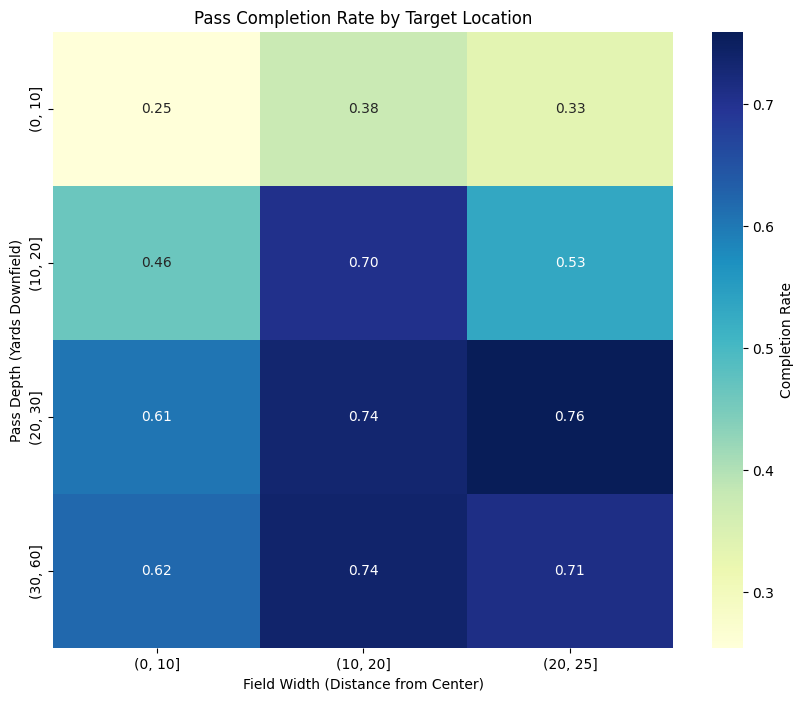

In [49]:
plt.figure(figsize=(10, 8))

target_plays = qb_features_essential.dropna(subset=['target_depth', 'target_width'])

x_bins = [0, 10, 20, 30, 60]
y_bins = [-25, -10, 10, 25]

target_plays['depth_zone'] = pd.cut(target_plays['target_depth'], bins=x_bins)
target_plays['width_zone'] = pd.cut(target_plays['target_width'].abs(), bins=[0, 10, 20, 25])

completion_matrix = target_plays.groupby(['depth_zone', 'width_zone'])['completion'].mean().unstack()

plt.title('Pass Completion Rate by Target Location')
sns.heatmap(completion_matrix, cmap='YlGnBu', annot=True, fmt='.2f', 
            cbar_kws={'label': 'Completion Rate'})
plt.xlabel('Field Width (Distance from Center)')
plt.ylabel('Pass Depth (Yards Downfield)')


# Player_Play EDA + Feature Engineering

In [50]:
player_play_df = pd.read_csv('../data/raw/player_play.csv', 
                           quotechar='"', 
                           na_values=['NA', 'na', 'N/A'],
                           dtype={'gameId': str, 'playId': int, 'nflId': int})


players_df = pd.read_csv('../data/raw/players.csv', dtype={'nflId': int})

passing_plays = plays_df[plays_df['passResult'].notna()]
passing_play_ids = passing_plays[['gameId', 'playId']].drop_duplicates()

passing_player_plays = player_play_df.merge(
    passing_play_ids,
    on=['gameId', 'playId'],
    how='inner'
)

if 'position' in players_df.columns:
    passing_player_plays = passing_player_plays.merge(
        players_df[['nflId', 'position']],
        on='nflId',
        how='left'
    )

In [51]:
# 1. IDENTIFY RECEIVERS
receivers = passing_player_plays[
    (passing_player_plays['wasTargettedReceiver'] == True) | 
    (passing_player_plays['wasRunningRoute'] == True) |
    (passing_player_plays['hadPassReception'] == True)
]

In [52]:
# 2. RECEIVER PERFORMANCE METRICS
receiver_game_stats = receivers.groupby(['gameId', 'nflId']).agg(
    targets=('wasTargettedReceiver', 'sum'),
    receptions=('hadPassReception', 'sum'),
    yards=('receivingYards', 'sum'),
    yac=('yardageGainedAfterTheCatch', 'sum'),
    drops=('wasTargettedReceiver', lambda x: sum(x) - sum(receivers.loc[x.index, 'hadPassReception']))
).reset_index()

receiver_game_stats['catch_rate'] = receiver_game_stats['receptions'] / receiver_game_stats['targets']
receiver_game_stats['catch_rate'] = receiver_game_stats['catch_rate'].fillna(0)


In [53]:
# 3. ROUTE INFORMATION
receiver_routes = receivers[receivers['routeRan'].notna()].copy()
receiver_routes['route_type'] = receiver_routes['routeRan']


In [54]:
# 4. COVERAGE MATCHUPS
receiver_coverage = receivers[receivers['pff_defensiveCoverageAssignment'].notna()].copy()
receiver_coverage['coverage_type'] = receiver_coverage['pff_defensiveCoverageAssignment']
receiver_coverage['primary_defender'] = receiver_coverage['pff_primaryDefensiveCoverageMatchupNflId']


In [55]:
# 1. RECEIVER AVAILABILITY ON EACH PLAY
play_receivers = receivers.groupby(['gameId', 'playId']).apply(
    lambda x: pd.Series({
        'available_receivers': x['nflId'].tolist(),
        'num_receivers': len(x),
        'targeted_receiver': x.loc[x['wasTargettedReceiver'] == True, 'nflId'].values[0] 
        if any(x['wasTargettedReceiver']) else None
    })
).reset_index()

C:\Users\jason\AppData\Local\Temp\ipykernel_29080\25518771.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  play_receivers = receivers.groupby(['gameId', 'playId']).apply(


In [56]:
# 2. HISTORICAL SUCCESS RATE FOR EACH RECEIVER
def calculate_rolling_stats(df):
    df = df.sort_values(['gameId', 'playId'])
    
    rolling_stats = {}
    
    all_stats = []
    for (game_id, play_id), play_data in df.groupby(['gameId', 'playId']):
        for _, receiver in play_data.iterrows():
            nfl_id = receiver['nflId']
            
            if nfl_id not in rolling_stats:
                rolling_stats[nfl_id] = {
                    'targets': 0,
                    'receptions': 0,
                    'yards': 0,
                    'yac': 0
                }
            
            current_stats = rolling_stats[nfl_id].copy()
            current_stats.update({
                'gameId': game_id,
                'playId': play_id,
                'nflId_': nfl_id
            })
            
            all_stats.append(current_stats)
            
            if receiver['wasTargettedReceiver']:
                rolling_stats[nfl_id]['targets'] += 1
            
            if receiver['hadPassReception']:
                rolling_stats[nfl_id]['receptions'] += 1
                rolling_stats[nfl_id]['yards'] += receiver['receivingYards'] or 0
                rolling_stats[nfl_id]['yac'] += receiver['yardageGainedAfterTheCatch'] or 0
    
    rolling_df = pd.DataFrame(all_stats)
    
    if not rolling_df.empty:
        rolling_df['catch_rate'] = rolling_df.apply(
            lambda x: x['receptions'] / x['targets'] if x['targets'] > 0 else 0, axis=1
        )
        rolling_df['avg_yards_per_reception'] = rolling_df.apply(
            lambda x: x['yards'] / x['receptions'] if x['receptions'] > 0 else 0, axis=1
        )
        rolling_df['avg_yac'] = rolling_df.apply(
            lambda x: x['yac'] / x['receptions'] if x['receptions'] > 0 else 0, axis=1
        )
    
    return rolling_df


In [57]:
# 3. MERGE WITH PLAYS DATA TO GET SITUATIONAL CONTEXT
target_outcomes = passing_player_plays[passing_player_plays['wasTargettedReceiver'] == True].merge(
    plays_df[['gameId', 'playId', 'yardsGained', 'passResult', 'expectedPointsAdded']],
    on=['gameId', 'playId'],
    how='left'
)

target_outcomes['completed'] = (target_outcomes['passResult'] == 'C').astype(int)
target_outcomes['positive_epa'] = (target_outcomes['expectedPointsAdded'] > 0).astype(int)

In [58]:
# 4. CREATE RECEIVER TARGET FEATURE MATRIX
def create_receiver_target_features(passing_player_plays, plays_df, player_df=None):
    passing_plays = plays_df[plays_df['passResult'].notna()]
    
    route_runners = passing_player_plays[
        (passing_player_plays['wasRunningRoute'] == True) | 
        (passing_player_plays['wasTargettedReceiver'] == True)
    ]
    
    if player_df is not None:
        route_runners = route_runners.merge(
            player_df[['nflId', 'position', 'height', 'weight']], 
            on='nflId', 
            how='left'
        )
    
    feature_rows = []
    
    for (game_id, play_id), play_receivers in route_runners.groupby(['gameId', 'playId']):
        play_data = passing_plays[(passing_plays['gameId'] == game_id) & 
                                 (passing_plays['playId'] == play_id)]
        
        if play_data.empty:
            continue
            
        play_info = play_data.iloc[0]
        
        targeted_receiver = play_receivers[play_receivers['wasTargettedReceiver'] == True]
        actual_target_id = targeted_receiver['nflId'].values[0] if not targeted_receiver.empty else None
        
        for _, receiver in play_receivers.iterrows():
            receiver_id = receiver['nflId']
            
            row = {
                'gameId': game_id,
                'playId': play_id,
                'nflId': receiver_id,
                
                # Target indicator (our label)
                'was_targeted': 1 if receiver_id == actual_target_id else 0,
                
                # Receiver route info
                'route_ran': receiver['routeRan'],
                
                # Coverage info
                'coverage_assignment': receiver.get('pff_defensiveCoverageAssignment', None),
                
                # Basic play context from plays.csv
                'down': play_info['down'],
                'yards_to_go': play_info['yardsToGo'],
                'yards_from_goal': 100 - play_info['absoluteYardlineNumber'],
                'quarter': play_info['quarter'],
            }
            
            feature_rows.append(row)
    
    return pd.DataFrame(feature_rows)

receiver_features = create_receiver_target_features(
    passing_player_plays, 
    plays_df, 
    players_df if 'position' in players_df.columns else None
)

receiver_features.to_csv('../data/processed/receiver_target_features.csv', index=False)

# Players EDA + Feature Engineering

In [59]:
players_df = pd.read_csv('../data/raw/players.csv', 
                        quotechar='"', 
                        na_values=['NA', 'na', 'N/A'],
                        dtype={'nflId': int})

In [60]:
# 1. HEIGHT CONVERSION
def convert_height_to_inches(height_str):
    """Convert height from string format (e.g., '6-4') to inches (76)"""
    if pd.isna(height_str):
        return np.nan
    
    try:
        feet, inches = height_str.split('-')
        return int(feet) * 12 + int(inches)
    except:
        return np.nan

players_df['height_inches'] = players_df['height'].apply(convert_height_to_inches)

In [61]:
# 2. CALCULATE AGE
def calculate_age(birth_date):
    if pd.isna(birth_date):
        return np.nan
    
    try:
        current_date = datetime(2022, 9, 1)
        
        birth = datetime.strptime(birth_date, '%Y-%m-%d')
        
        age = current_date.year - birth.year - ((current_date.month, current_date.day) < 
                                               (birth.month, birth.day))
        return age
    except:
        return np.nan

players_df['age'] = players_df['birthDate'].apply(calculate_age)

In [62]:
# 3. POSITION GROUPING
position_groups = {
    'QB': 'QB',
    'RB': 'RB',
    'FB': 'RB',
    'WR': 'WR',
    'TE': 'TE',
    'LT': 'OL', 'LG': 'OL', 'C': 'OL', 'RG': 'OL', 'RT': 'OL',
    'OL': 'OL', 'T': 'OL', 'G': 'OL',
    'DE': 'DL', 'NT': 'DL', 'DT': 'DL', 'DL': 'DL',
    'OLB': 'LB', 'ILB': 'LB', 'MLB': 'LB', 'LB': 'LB',
    'CB': 'DB', 'DB': 'DB', 'FS': 'DB', 'SS': 'DB', 'S': 'DB',
    'K': 'ST', 'P': 'ST', 'LS': 'ST'
}

players_df['position_group'] = players_df['position'].map(position_groups)

In [63]:
# 4. RECEIVER TYPE CLASSIFICATION
players_df['is_receiver'] = players_df['position'].isin(['WR', 'TE', 'RB'])

def classify_receiver_type(row):
    if not row['is_receiver']:
        return np.nan
    
    if row['position'] == 'TE':
        return 'TE'
    
    if row['position'] == 'RB':
        return 'RB'
    
    if pd.notna(row['height_inches']):
        if row['height_inches'] >= 74:
            return 'big_receiver'
        elif row['height_inches'] <= 70:
            return 'small_receiver'
        else:
            return 'medium_receiver'
    
    return 'unknown_receiver'

players_df['receiver_type'] = players_df.apply(classify_receiver_type, axis=1)

In [64]:
# 5. PHYSICAL METRICS
players_df['bmi'] = players_df.apply(
    lambda row: row['weight'] / (row['height_inches'] ** 2) * 703 
    if pd.notna(row['weight']) and pd.notna(row['height_inches']) else np.nan, 
    axis=1
)

In [65]:
# 6. ADDITIONAL FEATURES FOR RECEIVER TRAITS
db_avg_height = players_df[players_df['position_group'] == 'DB']['height_inches'].mean()
players_df['height_vs_db'] = players_df['height_inches'] - db_avg_height
db_avg_weight = players_df[players_df['position_group'] == 'DB']['weight'].mean()
players_df['weight_vs_db'] = players_df['weight'] - db_avg_weight

In [66]:
player_features = players_df[[
    'nflId', 'displayName', 'position', 'position_group',
    'height_inches', 'weight', 'age', 
    'is_receiver', 'receiver_type', 'bmi', 'height_vs_db',
    'weight_vs_db'
]]

player_features.to_csv('../data/processed/player_features.csv', index=False)

In [67]:
qb_features = players_df[players_df['position'] == 'QB'].copy()

qb_features['experience_level'] = pd.cut(
    qb_features['age'],
    bins=[0, 25, 30, 35, 100],
    labels=['rookie_young', 'prime', 'veteran', 'senior']
)

qb_features[[
    'nflId', 'displayName', 'height_inches', 'weight', 
    'age', 'experience_level', 'bmi'
]].to_csv('../data/processed/quarterback_features.csv', index=False)

# Tracking Weeks EDA + Feature Engineering

In [68]:
def extract_week_number(filename):
    match = re.search(r'week[_]?(\d+)', filename.lower())
    if match:
        return int(match.group(1))
    return None

In [69]:
def process_multi_week_tracking_data(tracking_file_pattern='../data/tracking_week_*.csv'):
    tracking_files = glob.glob(tracking_file_pattern)
    
    if not tracking_files:
        print(f"No tracking files found matching pattern: {tracking_file_pattern}")
        return None
    
    print(f"Found {len(tracking_files)} tracking files to process")
    
    all_weeks_features = []
    
    for file_path in tracking_files:
        week_number = extract_week_number(file_path)
        
        if week_number is None:
            file_index = tracking_files.index(file_path) + 1
            print(f"Week number not found in filename {file_path}. Using index {file_index} as week number.")
            week_number = file_index
        
        print(f"Processing Week {week_number} data from {file_path}")
        
        tracking_df = pd.read_csv(file_path, 
                                quotechar='"', 
                                na_values=['NA', 'na', 'N/A'])
        
        tracking_df['week'] = week_number
        
        tracking_df['time'] = pd.to_datetime(tracking_df['time'], format='mixed', errors='coerce')
        if tracking_df['time'].isna().any():
            print(f"Warning: {tracking_df['time'].isna().sum()} timestamp(s) could not be parsed in Week {week_number}")
        
        # 1. BASIC CLEANING AND PREPROCESSING
        tracking_df['event'] = tracking_df['event'].fillna('NO_EVENT')
        tracking_df['play_key'] = tracking_df['gameId'].astype(str) + '_' + tracking_df['playId'].astype(str)
        
        # 2. TEMPORAL FEATURES
        tracking_df = tracking_df.groupby(['gameId', 'playId']).apply(calculate_elapsed_time)
        tracking_df = tracking_df.reset_index(drop=True)
        
        tracking_df['is_pre_snap'] = tracking_df['frameType'] == 'BEFORE_SNAP'
        
        # 3. MOVEMENT FEATURES
        tracking_df['dir_rad'] = np.radians(tracking_df['dir'])
        
        # Calculate velocity vectors
        tracking_df['velocity_x'] = tracking_df['s'] * np.sin(tracking_df['dir_rad'])
        tracking_df['velocity_y'] = tracking_df['s'] * np.cos(tracking_df['dir_rad'])
        
        # Calculate acceleration vectors
        tracking_df['accel_x'] = tracking_df['a'] * np.sin(tracking_df['dir_rad'])
        tracking_df['accel_y'] = tracking_df['a'] * np.cos(tracking_df['dir_rad'])
        
        # 4. ORIENTATION FEATURES
        tracking_df['o_rad'] = np.radians(tracking_df['o'])
        
        tracking_df['facing_x'] = np.sin(tracking_df['o_rad'])
        tracking_df['facing_y'] = np.cos(tracking_df['o_rad'])
        
        tracking_df['movement_alignment'] = tracking_df.apply(calculate_alignment, axis=1)
        
        # 5. SPATIAL FEATURES
        tracking_df['distance_from_sideline'] = np.minimum(tracking_df['y'], 53.3 - tracking_df['y'])
        
        tracking_df['adjusted_x'] = tracking_df.apply(
            lambda row: row['x'] if row['playDirection'] == 'right' else 120 - row['x'], 
            axis=1
        )
        
        # 6. PLAYER-SPECIFIC AGGREGATED FEATURES
        play_player_stats = tracking_df.groupby(['gameId', 'playId', 'nflId', 'displayName']).agg({
            's': ['mean', 'max', 'std'],
            'a': ['mean', 'max', 'std'],
            'dis': 'sum',
            'movement_alignment': 'mean',
            'x': ['min', 'max'],
            'y': ['min', 'max'],
            'week': 'first'
        })
        
        play_player_stats.columns = ['_'.join(col).strip() for col in play_player_stats.columns.values]
        play_player_stats = play_player_stats.reset_index()
        
        play_player_stats['x_distance'] = play_player_stats['x_max'] - play_player_stats['x_min']
        play_player_stats['y_distance'] = play_player_stats['y_max'] - play_player_stats['y_min']
        
        play_player_stats['route_directness'] = play_player_stats.apply(
            lambda row: math.sqrt(row['x_distance']**2 + row['y_distance']**2) / row['dis_sum'] 
            if row['dis_sum'] > 0 else np.nan,
            axis=1
        )
        
        # 7. DIRECTION CHANGE DETECTION
        direction_changes = tracking_df.groupby(['gameId', 'playId', 'nflId']).apply(count_direction_changes)
        direction_changes = direction_changes.reset_index()
        direction_changes.columns = ['gameId', 'playId', 'nflId', 'direction_changes']
        
        # 8. PLAY PHASE ANALYSIS
        tracking_df = tracking_df.groupby(['gameId', 'playId']).apply(classify_play_phase)
        tracking_df = tracking_df.reset_index(drop=True)
        
        phase_features = tracking_df.groupby(['gameId', 'playId', 'nflId', 'play_phase']).agg({
            's': ['mean', 'max'],
            'a': ['mean', 'max'],
            'dis': 'sum',
            'frameId': 'count'
        }).reset_index()
        
        phase_features.columns = ['_'.join(col).strip() if col[1] else col[0] for col in phase_features.columns]
        
        phase_pivot = phase_features.pivot_table(
            index=['gameId', 'playId', 'nflId'],
            columns='play_phase',
            values=['s_mean', 's_max', 'dis_sum', 'frameId_count']
        )
        
        phase_pivot.columns = ['_'.join(col).strip() for col in phase_pivot.columns.values]
        phase_pivot = phase_pivot.reset_index()
        
        # 9. MERGE ALL FEATURES FOR THIS WEEK
        week_features = pd.merge(
            play_player_stats,
            direction_changes,
            on=['gameId', 'playId', 'nflId']
        )
        
        week_features = pd.merge(
            week_features,
            phase_pivot,
            on=['gameId', 'playId', 'nflId'],
            how='left'
        )
        
        all_weeks_features.append(week_features)
        
        print(f"Processed {len(week_features)} player-play combinations for Week {week_number}")
    
    if all_weeks_features:
        combined_features = pd.concat(all_weeks_features, ignore_index=True)
        print(f"Combined dataset contains {len(combined_features)} rows across {len(all_weeks_features)} weeks")
        
        output_path = "../data/processed/multi_week_player_tracking_features.csv"
        combined_features.to_csv(output_path, index=False)
        print(f"Exported combined features to {output_path}")
        
        return combined_features
    else:
        print("No data processed")
        return None

def calculate_elapsed_time(group):
    group = group.sort_values('frameId')
    first_time = group['time'].min()
    group['seconds_elapsed'] = (group['time'] - first_time).dt.total_seconds()
    return group

def calculate_alignment(row):
    if row['s'] < 0.5:
        return np.nan
    
    dir_x = np.sin(np.radians(row['dir']))
    dir_y = np.cos(np.radians(row['dir']))
    
    return dir_x * row['facing_x'] + dir_y * row['facing_y']

def count_direction_changes(group, threshold=30):
    if len(group) < 3:
        return 0
    
    group = group.sort_values('frameId')
    
    moving_frames = group[group['s'] > 1.0]
    if len(moving_frames) < 3:
        return 0
    
    prev_dir = None
    changes = 0
    
    for _, frame in moving_frames.iterrows():
        curr_dir = frame['dir']
        
        if prev_dir is not None:
            angle_diff = min((curr_dir - prev_dir) % 360, (prev_dir - curr_dir) % 360)
            if angle_diff > threshold:
                changes += 1
        
        prev_dir = curr_dir
    
    return changes

def classify_play_phase(group):
    group = group.sort_values('frameId')
    
    snap_frames = group[group['event'] == 'ball_snap']['frameId'].tolist()
    if not snap_frames:
        group['play_phase'] = group['frameType']
        return group
    
    snap_frame = min(snap_frames)
    
    group['play_phase'] = 'UNKNOWN'
    group.loc[group['frameId'] < snap_frame, 'play_phase'] = 'PRE_SNAP'
    group.loc[group['frameId'] >= snap_frame, 'play_phase'] = 'POST_SNAP'
    
    pass_frames = group[group['event'] == 'pass']['frameId'].tolist()
    if pass_frames:
        pass_frame = min(pass_frames)
        group.loc[group['frameId'] >= pass_frame, 'play_phase'] = 'POST_PASS'
    
    return group

def create_week_over_week_visualizations(combined_features, output_dir="../visualizations"):
    
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. PLAYER SPEED PROGRESSION ACROSS WEEKS
    top_speed_players = combined_features.groupby(['nflId', 'displayName'])['s_mean'].mean().nlargest(10)
    top_player_ids = top_speed_players.index.get_level_values('nflId')
    
    top_player_data = combined_features[combined_features['nflId'].isin(top_player_ids)]
    
    player_weekly_speed = top_player_data.groupby(['nflId', 'displayName', 'week_first'])['s_mean'].mean().reset_index()
    
    plt.figure(figsize=(12, 8))
    for player_id in top_player_ids:
        player_data = player_weekly_speed[player_weekly_speed['nflId'] == player_id]
        player_name = player_data['displayName'].iloc[0] if not player_data.empty else f"Player {player_id}"
        plt.plot(player_data['week_first'], player_data['s_mean'], marker='o', linewidth=2, label=player_name)
    
    plt.title('Top 10 Player Average Speed Progression by Week', fontsize=14)
    plt.xlabel('Week', fontsize=12)
    plt.ylabel('Average Speed (yards/second)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/top_player_speed_by_week.png")
    plt.close()
    
    # 2. POSITION GROUP PERFORMANCE BY WEEK
    np.random.seed(42)  # For reproducibility
    unique_players = combined_features[['nflId', 'displayName']].drop_duplicates()
    positions = ['QB', 'WR', 'RB', 'TE', 'OL', 'DL', 'LB', 'DB']
    unique_players['position'] = np.random.choice(positions, size=len(unique_players))
    
    combined_features_with_pos = pd.merge(
        combined_features, 
        unique_players[['nflId', 'position']], 
        on='nflId',
        how='left'
    )
    
    position_weekly_metrics = combined_features_with_pos.groupby(['position', 'week_first']).agg({
        's_mean': 'mean',
        'dis_sum': 'mean',
        'route_directness': 'mean'
    }).reset_index()
    
    plt.figure(figsize=(12, 8))
    for position in positions:
        pos_data = position_weekly_metrics[position_weekly_metrics['position'] == position]
        if not pos_data.empty:
            plt.plot(pos_data['week_first'], pos_data['s_mean'], marker='o', linewidth=2, label=position)
    
    plt.title('Average Speed by Position Group Across Weeks', fontsize=14)
    plt.xlabel('Week', fontsize=12)
    plt.ylabel('Average Speed (yards/second)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/position_speed_by_week.png")
    plt.close()
    
    # 3. PLAYER RADAR CHARTS SHOWING PROGRESSION
    if not top_player_ids.empty:
        example_player_id = top_player_ids[0]
        example_player_data = combined_features[combined_features['nflId'] == example_player_id]
        
        if not example_player_data.empty:
            player_name = example_player_data['displayName'].iloc[0]
            
            weeks = sorted(example_player_data['week_first'].unique())
            metrics = ['s_mean', 's_max', 'route_directness', 'dis_sum']
            
            normalized_data = {}
            
            for metric in metrics:
                min_val = combined_features[metric].min()
                max_val = combined_features[metric].max()
                
                if max_val > min_val:
                    normalized_data[metric] = {}
                    for week in weeks:
                        week_val = example_player_data[example_player_data['week_first'] == week][metric].mean()
                        normalized_data[metric][week] = (week_val - min_val) / (max_val - min_val)
            
            num_metrics = len(metrics)
            angles = np.linspace(0, 2*np.pi, num_metrics, endpoint=False).tolist()
            angles += angles[:1] 
            
            fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))
            
            for week in weeks:
                values = [normalized_data[metric][week] for metric in metrics]
                values += values[:1] 
                
                ax.plot(angles, values, linewidth=2, label=f'Week {week}')
                ax.fill(angles, values, alpha=0.1)
            
            # Add labels
            ax.set_xticks(angles[:-1])
            ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics])
            ax.set_title(f"{player_name}'s Performance Progression Across Weeks", fontsize=15, y=1.1)
            ax.legend(loc='upper right')
            
            plt.tight_layout()
            plt.savefig(f"{output_dir}/player_{example_player_id}_progression_radar.png")
            plt.close()
    
    # 4. ROUTE DIRECTNESS DISTRIBUTION BY WEEK
    plt.figure(figsize=(12, 8))
    for week in sorted(combined_features['week_first'].unique()):
        week_data = combined_features[combined_features['week_first'] == week]
        
        # Only consider reasonable values between 0 and 1
        valid_data = week_data[(week_data['route_directness'] >= 0) & (week_data['route_directness'] <= 1)]
        
        if len(valid_data) > 0:
            sns.kdeplot(valid_data['route_directness'], label=f'Week {week}')
    
    plt.title('Route Directness Distribution by Week', fontsize=14)
    plt.xlabel('Route Directness (0-1, higher is more direct)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{output_dir}/route_directness_by_week.png")
    plt.close()
    
    print(f"Created week-over-week visualizations in {output_dir}")


In [70]:
combined_data = process_multi_week_tracking_data('../data/tracking_week_*.csv')
if combined_data is not None:
    create_week_over_week_visualizations(combined_data)

Found 9 tracking files to process
Processing Week 1 data from ../data\tracking_week_1.csv


C:\Users\jason\AppData\Local\Temp\ipykernel_29080\3537415952.py:37: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df = tracking_df.groupby(['gameId', 'playId']).apply(calculate_elapsed_time)


KeyboardInterrupt: 